<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


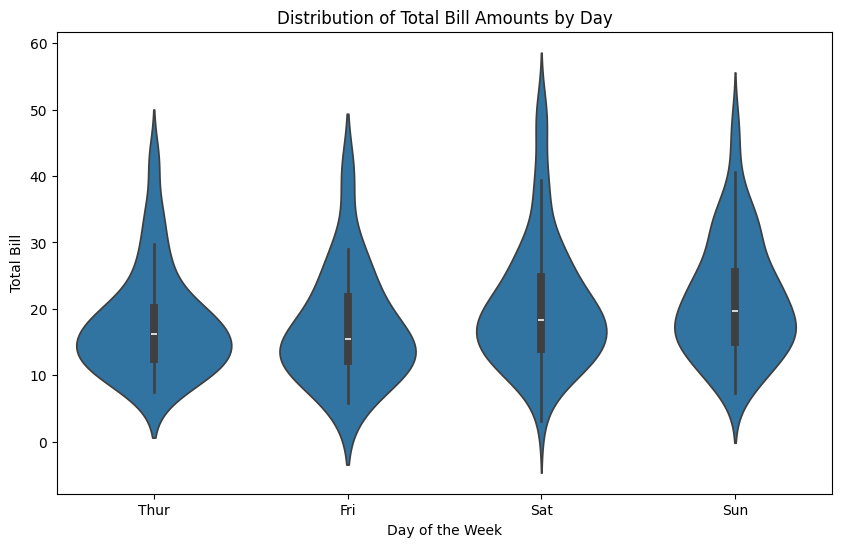

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the example dataset
tips = sns.load_dataset("tips")

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="day", y="total_bill", data=tips)

# Add labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Total Bill")
plt.title("Distribution of Total Bill Amounts by Day")

# Show the plot
plt.show()


In [1]:
action = [1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 0.6923076923076923, -1.0, 0.6923076923076923, 0.6923076923076923, 0.23076923076923084, 0.23076923076923084, 0.6923076923076923, 0.6923076923076923, -1.0]

In [2]:
import Union
import numpy as np
from typing import List, Tuple, Any
def _setpoints_transform_gpt(
        self, action: Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]
    ) -> Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
        """This method transforms an action defined in gym
        (-1,1 in all continuous environment) action space
        to simulation real action space.

        Args:
            action (Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]):
            Action received in environment

        Returns:
            Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
            Action transformed in simulator action space.
        """
        action_ = []



        for i, value in enumerate(action):


            if self.action_space.low[i] <= value <= self.action_space.high[i]:
                a_max_min = self.action_space.high[i] - self.action_space.low[i]


                if self.action_discretization:
                    if self.variables["action"][i] in self.action_discretization.keys():
                        discrete_actions = self.action_discretization[
                            self.variables["action"][i]
                        ]
                        value = find_nearest(discrete_actions, value)

                override = False
                if (
                    self.incremental_action
                    and self.variables["action"][i] in self.incremental_action.keys()
                ):
                    inc_entry = self.incremental_action[self.variables["action"][i]]
                    if self.obs_dict:
                        new_value = self.obs_dict[inc_entry[0]] + value * inc_entry[1]
                    else:
                        new_value = inc_entry[2] + value * inc_entry[1]

                    # Ensure the new_value does not exceed action space bounds
                    new_value = max(min(new_value, self.action_space.high[i]), self.action_space.low[i])
                    action_.append(new_value)
                    override = True

                    # limit setpoint space

                    done = False
                    if self.action_remapping:
                        if self.variables["action"][i] in self.action_remapping.keys():
                            remap = self.action_remapping[self.variables["action"][i]]
                            if self.obs_dict:
                                condts_met = [True] * len(remap)
                                for i_rm, rm in enumerate(remap):
                                    for condt in rm[0]:
                                        if not condt[1](
                                            self.obs_dict[condt[0]], condt[2]
                                        ):
                                            condts_met[i_rm] = False

                                for i_cm, cm in enumerate(condts_met):
                                    if cm:
                                        action_[-1] = max(
                                            min(action_[-1], remap[i_cm][2]),
                                            remap[i_cm][1],
                                        )
                                        done = True

                    if not done:
                        action_[-1] = max(
                            min(action_[-1], self.setpoints_space.high[i]),
                            self.setpoints_space.low[i],
                        )

                # apply action remapping

                elif self.action_remapping:
                    if self.variables["action"][i] in self.action_remapping.keys():
                        remap = self.action_remapping[self.variables["action"][i]]
                        if self.obs_dict:

                            condts_met = [True] * len(remap)
                            for i_rm, rm in enumerate(remap):
                                for condt in rm[0]:
                                    if not condt[1](self.obs_dict[condt[0]], condt[2]):
                                        condts_met[i_rm] = False

                            for i_cm, cm in enumerate(condts_met):
                                if cm:
                                    sp_max_min = remap[i_cm][2] - remap[i_cm][1]
                                    new_value = remap[i_cm][1] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                                    action_.append(new_value)
                                    override = True



                if not override:
                    sp_max_min = (
                        self.setpoints_space.high[i] - self.setpoints_space.low[i]
                    )
                    new_value = self.setpoints_space.low[i] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                    action_.append(new_value)



            else:
                # If action is outer action_space already, it doesn't need transformation
                action_.append(value)

        return action_

NameError: name 'Union' is not defined

In [1]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [1]:
import numpy as np

In [3]:
def draw_set_temp(distribution="Huebner2013_UK", temp_control_seed=None):
    """Draw a thermostat set temp from a distribution."""
    if temp_control_seed is not None:
        np.random.seed(temp_control_seed)

    if distribution == "Huebner2013_UK":
        p = np.array(
            [
                0.01,
                0.02,
                0.01,
                0.03,
                0.04,
                0.08,
                0.16,
                0.14,
                0.16,
                0.16,
                0.09,
                0.05,
                0.03,
                0.01,
                0.01,
            ]
        )
        return np.random.choice(
            [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], p=p / sum(p)
        )
    elif distribution == "EFUS2017_UK":
        p = np.array(
            [
                0.003,
                0.002,
                0.002,
                0.022,
                0.021,
                0.046,
                0.144,
                0.096,
                0.265,
                0.151,
                0.096,
                0.035,
                0.020,
                0.057,
                0.009,
                0.003,
                0.008,
                0.002,
                0.019,
            ]
        )
        return np.random.choice(
            [
                10,
                13,
                14,
                15,
                16,
                17,
                18,
                19,
                20,
                21,
                22,
                23,
                24,
                25,
                26,
                27,
                28,
                29,
                30,
            ],
            p=p / sum(p),
        )
    else:
        return 20.0


once_code_schedule = [(6, 23)]
twice_code_schedule = [(6, 9), (16, 23)]
thrice_code_schedule = [(6, 8), (12, 14), (18, 23)]


def get_onoff_times(sch_name, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if sch_name == "once_CODE":
        return once_code_schedule
    elif sch_name == "twice_CODE":
        return twice_code_schedule
    elif sch_name == "thrice_CODE":
        return thrice_code_schedule
    elif sch_name == "random":
        index = np.random.choice([1, 2, 3], p=[0.23, 0.58, 0.19])
        if index == 1:
            return once_code_schedule
        elif index == 2:
            return twice_code_schedule
        else:
            return thrice_code_schedule

In [29]:
get_onoff_times("random", seed=5)

[(6, 23)]

In [18]:
draw_set_temp(distribution = "EFUS2017_UK", temp_control_seed=15)

23

In [62]:
import requests
import pandas as pd
from datetime import datetime, timedelta

headers = {
    'Accept': 'application/json'
}

# Define the start and end dates for the year
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 2)

# Function to get data for a given period
def get_data_for_period(start, end):
    from_ = start.strftime("%Y-%m-%dT%H:%MZ")
    to = end.strftime("%Y-%m-%dT%H:%MZ")
    r = requests.get(f"https://api.carbonintensity.org.uk/intensity/{from_}/{to}", headers=headers)
    return r.json()

# List to hold all data
all_data = []

# Loop through the year in 30-day increments
current_start = start_date
while current_start < end_date:
    current_end = current_start + timedelta(days=30)
    if current_end > end_date:
        current_end = end_date
    print(f"Fetching data from {current_start} to {current_end}")
    response = get_data_for_period(current_start, current_end)
    all_data.extend(response['data'])
    current_start = current_end

# Extract time and actual emissions
data = []
for entry in all_data:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df1 = pd.DataFrame(data)

# Print DataFrame
df1


Fetching data from 2023-01-01 00:00:00 to 2023-01-31 00:00:00
Fetching data from 2023-01-31 00:00:00 to 2023-03-02 00:00:00
Fetching data from 2023-03-02 00:00:00 to 2023-04-01 00:00:00
Fetching data from 2023-04-01 00:00:00 to 2023-05-01 00:00:00
Fetching data from 2023-05-01 00:00:00 to 2023-05-31 00:00:00
Fetching data from 2023-05-31 00:00:00 to 2023-06-30 00:00:00
Fetching data from 2023-06-30 00:00:00 to 2023-07-30 00:00:00
Fetching data from 2023-07-30 00:00:00 to 2023-08-29 00:00:00
Fetching data from 2023-08-29 00:00:00 to 2023-09-28 00:00:00
Fetching data from 2023-09-28 00:00:00 to 2023-10-28 00:00:00
Fetching data from 2023-10-28 00:00:00 to 2023-11-27 00:00:00
Fetching data from 2023-11-27 00:00:00 to 2023-12-27 00:00:00
Fetching data from 2023-12-27 00:00:00 to 2024-01-02 00:00:00


,time,actual_emissions
0,2022-12-31T23:30Z,65.0
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
...,...,...
17485,2024-01-01T21:30Z,42.0
17486,2024-01-01T22:00Z,46.0
17487,2024-01-01T22:30Z,49.0
17488,2024-01-01T23:00Z,50.0


In [65]:
df1.iloc[1:17443,:]

,time,actual_emissions
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
5,2023-01-01T02:00Z,65.0
...,...,...
17438,2023-12-31T22:00Z,63.0
17439,2023-12-31T22:30Z,65.0
17440,2023-12-31T23:00Z,62.0
17441,2023-12-31T23:30Z,63.0


In [66]:
df1.iloc[1:17443,:].to_csv("emissions_grid_intensity.csv", index=False)

In [85]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])

In [86]:
grid

,actual_emissions
time,
2023-01-01 00:00:00+00:00,72.0
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
...,...
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0
2023-12-31 23:00:00+00:00,62.0


In [87]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])
grid = grid[~grid.index.duplicated()]
interp_grid = grid.resample("10min").interpolate(method='linear')
interp_grid = interp_grid.iloc[:-1, :]
interp_grid = interp_grid.reset_index()

In [88]:
interp_grid.columns = [" ","GRID CARBON INTENSITY (gCO2/kWh)"]

In [89]:
interp_grid


,,GRID CARBON INTENSITY (gCO2/kWh)
0,2023-01-01 00:00:00+00:00,72.000000
1,2023-01-01 00:10:00+00:00,74.666667
2,2023-01-01 00:20:00+00:00,77.333333
3,2023-01-01 00:30:00+00:00,80.000000
4,2023-01-01 00:40:00+00:00,77.333333
...,...,...
52555,2023-12-31 23:10:00+00:00,62.333333
52556,2023-12-31 23:20:00+00:00,62.666667
52557,2023-12-31 23:30:00+00:00,63.000000
52558,2023-12-31 23:40:00+00:00,63.333333


In [90]:
interp_grid.to_csv("grid_carbon_GB_10min_2023.csv", index=False)

In [44]:


# Resample to 10-minute intervals and interpolate
try:
    df_resampled = grid.resample('10T').interpolate(method='linear')
except ValueError as e:
    print(f"Error during resampling/interpolation: {e}")
    # Handle the error as needed

# Print the resulting DataFrame
print(df_resampled)

/tmp/ipykernel_84183/2092384894.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [43]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0)
grid = grid.iloc[1:,:]
grid['time'] = pd.to_datetime(grid['time'])
grid.set_index('time', inplace=True)
df_resampled = grid.resample('10T').interpolate(method='linear')

/tmp/ipykernel_84183/2323822437.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


ValueError: cannot reindex on an axis with duplicate labels

KeyError: 'time'

In [22]:




# Set the time column as the index
df.set_index('time', inplace=True)

# Resample to 10-minute intervals and interpolate
#df_resampled = df.resample('10T').interpolate(method='linear')

# Reset the index to turn the time back into a column
#df_resampled.reset_index(inplace=True)

# Print the resulting DataFrame
#df_resampled

KeyError: 'time'

In [24]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [23]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [11]:
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [12]:
# Extract time and actual emissions
data = []
for entry in response['data']:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df = pd.DataFrame(data)

In [13]:
df

,time,actual_emissions
0,2022-12-31T23:30Z,65
1,2023-01-01T00:00Z,72
2,2023-01-01T00:30Z,80
3,2023-01-01T01:00Z,72
4,2023-01-01T01:30Z,65
5,2023-01-01T02:00Z,65
6,2023-01-01T02:30Z,65
7,2023-01-01T03:00Z,67
8,2023-01-01T03:30Z,68
9,2023-01-01T04:00Z,71


In [2]:
zone_names_flattened = ["kitchen", "living"]
controlled_zones = ["kitchen"]

# Using set operations to get the difference between the lists
manual_temp_control_names = list(set(zone_names_flattened) - set(controlled_zones))

print(manual_temp_control_names)


['living']


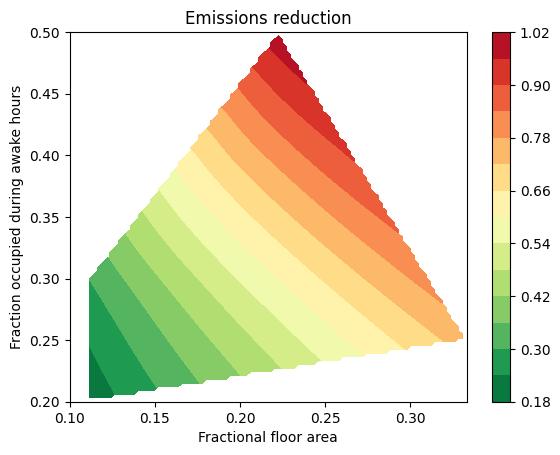

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

points = np.array([(2/9, 0.5), (1/9, 0.2), (2/9, 0.4), (3/9, 0.25), (1/9, 0.3)])
values = np.array([1, 0.2, 0.8, 0.75, 0.3])

grid_x, grid_y = np.mgrid[0.1:0.3333:100j, 0.2:0.5:100j]
grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

plt.contourf(grid_x, grid_y, grid_z, levels=14, cmap='RdYlGn_r')
plt.colorbar()
#plt.scatter(points[:, 0], points[:, 1], c='black')
plt.title('Emissions reduction')
plt.xlabel('Fractional floor area')
plt.ylabel('Fraction occupied during awake hours')
plt.show()
